In [1]:
import pandas as pd
import sqlite3

In [2]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

For each hour, calculate the average number of commits on working days and weekends. If there were no commits in an hour, do not use it to calculate the average. Use these values for your graph. For example: Monday, 17–18: 5 commits; Tuesday, 17–18: 6 commits; Wednesday, 17–18: 7 commits.

In [43]:
query = """
SELECT 
    CASE
        WHEN CAST(strftime('%w', timestamp) AS INTEGER) BETWEEN 1 AND 5 THEN 'working_day'
        ELSE 'weekend'
    END AS day,
    strftime('%H', timestamp) AS hour,
    DATE(timestamp) AS date,
    COUNT(*) as commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY
    CASE
        WHEN CAST(strftime('%w', timestamp) AS INTEGER) BETWEEN 1 AND 5 THEN 'working_day'
        ELSE 'weekend'
    END,
    strftime('%H', timestamp),
    DATE(timestamp);
"""


commits_df = pd.read_sql(query, conn)
print(commits_df)

             day hour        date  commits
0        weekend   00  2020-04-19        2
1        weekend   00  2020-04-26        2
2        weekend   00  2020-05-10        2
3        weekend   01  2020-05-10        6
4        weekend   03  2020-04-25        1
..           ...  ...         ...      ...
283  working_day   22  2020-05-14        8
284  working_day   22  2020-05-20        4
285  working_day   23  2020-05-11        4
286  working_day   23  2020-05-13        8
287  working_day   23  2020-05-20        3

[288 rows x 4 columns]


In [44]:
commits_df = commits_df.groupby(['day', 'hour'])['commits'].mean().reset_index()
commits_df

,day,hour,commits
0,weekend,00,2.000000
1,weekend,01,6.000000
2,weekend,03,1.000000
3,weekend,05,2.000000
4,weekend,07,4.000000
5,weekend,08,7.000000
6,weekend,09,3.666667
7,weekend,10,7.000000
8,weekend,11,23.600000
9,weekend,12,9.500000


In [45]:
commits_df['hour'] = commits_df['hour'].astype(int)

In [46]:
commits_df = commits_df.pivot(index='hour', columns='day', values='commits')
commits_df

day,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,NaN
3,1.000000,2.000000
5,2.000000,7.500000
6,NaN,1.500000
7,4.000000,5.166667
8,7.000000,3.700000
9,3.666667,6.000000
10,7.000000,13.200000


In [48]:
commits_df = commits_df.reindex(range(24)).fillna(0)
commits_df

day,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,0.000000
2,0.000000,0.000000
3,1.000000,2.000000
4,0.000000,0.000000
5,2.000000,7.500000
6,0.000000,1.500000
7,4.000000,5.166667
8,7.000000,3.700000


array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

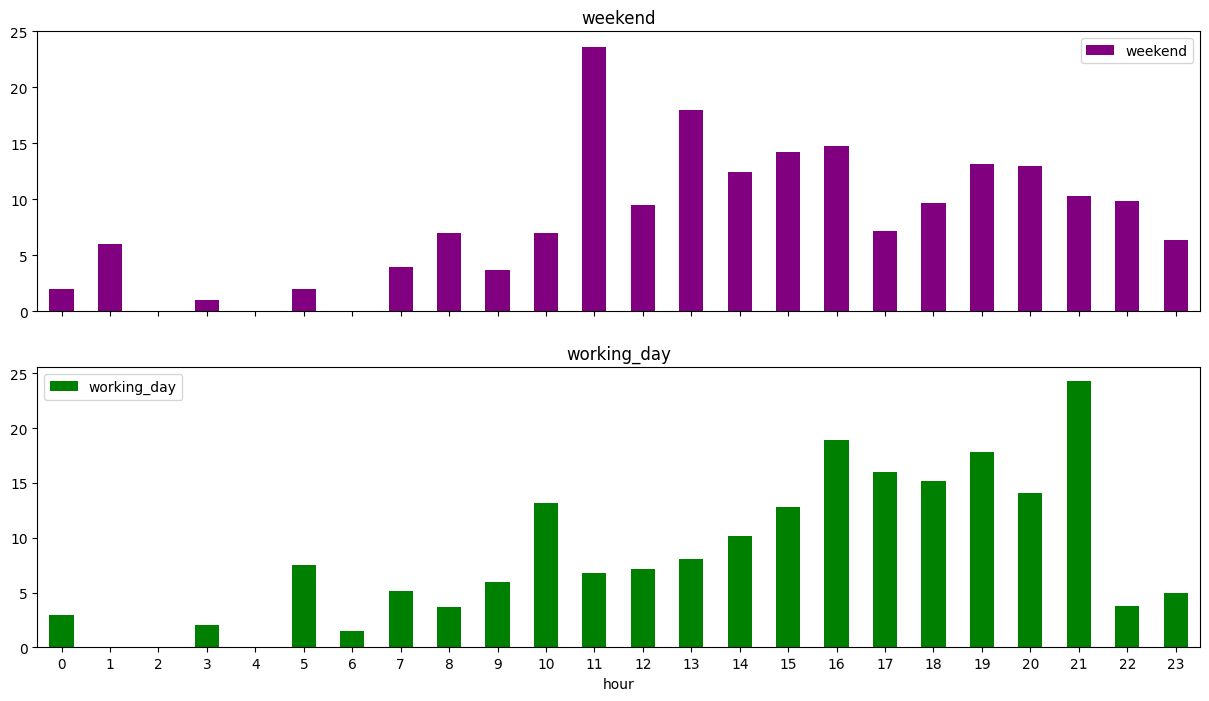

In [50]:
commits_df.plot(
    kind='bar',
    subplots=True,
    figsize=(15,8),
    sharex=True,
    rot=True,
    yticks=range(0, 30, 5), 
    color=['purple', 'green']
)

Is the dynamic different on working days and weekends? 
Yes. Working Days = 21:00, Weekend = 11:00

In [51]:
conn.close()